# Puzzle Velocity Analysis — Week Four

*Same question as [day 07](archive/day-07-analysis.ipynb): is the lccjs microtask estimator any good? Succeeds [day 11](archive/day-11-analysis.ipynb) — the last daily pass.*

**Cadence change:** analysis moves from **daily** to **weekly** as of 2026-06-14. The daily notebooks (`day-01`…`day-11`) are archived under `stats/archive/`; this is the first weekly-cadence pass (#1261).

**Week-four upgrades (vs week-03):**
- Data source: SQLite (`~/.lccjs/lccjs.db`) — no pipeline change.
- Window extended to **2026-06-29** (was 06-14 at week-03), so the corpus now spans weeks 1–5 (data logging began 2026-05-28).
- 🆕 RICE retired in favour of **ICE** (§9, #1519); 🆕 first-look **errors** (§8) and **issue-lifecycle** (§10) sections added.
- Week buckets (7-day from 05-28): wk1 05-28→06-03, wk2 06-04→06-10, wk3 06-11→06-17, wk4 06-18→06-24, wk5 06-25→07-01.

> **⚠ Rendered-run caveat (#1523):** §10a–§10d depend on a live `gh issue list` and **self-skip under headless `nbconvert`** — in the committed/rendered notebook those four charts are intentionally blank (see the §10 banner); §10e still runs from the velocity data.
> **Point-in-time snapshot:** the window includes the current day (2026-06-29, still in progress), so re-running ingests new rows — the figures below are *as of this run*, not a frozen window.

## TL;DR — what this notebook says (plain language)

- **The question.** When an AI agent predicts how long a task will take (its *C-estimate*), how close is that prediction to reality?
- **The headline.** Agents almost always finish **faster** than they predict. Across **1,068** timed tasks (all data through 2026-06-29), **~85% (908/1,068)** beat their own estimate, and the typical task takes about **40%** of the predicted time (median over-estimate ≈ **2.5×**).
- **🆕 Updated this week — the "learning curve" is non-monotone, not a continuing decline.** Over the whole window the day-by-day trend is still significantly downward (Spearman ρ = −0.59, p = 0.002). But the *weekly* view shows week 3 was a **trough**, not the start of a sustained drop: **wk1 3.6× → wk2 2.7× → wk3 1.3× → wk4 2.3× → wk5 1.7×**. Recent weeks bounced between ~1.7× and ~2.3× — well below week 1, but the fall is not monotone. week-03's "the learning curve has finally appeared" was premature.
- **The honest caveat.** Weeks 4–5 rest on thin counts (n = 11 and 60; a 5-day logging gap sits at 06-18→06-22). This is a correlational, observational trend — calendar time is confounded with task difficulty, model, and roster — so it describes *what happened*, not a cause.
- **What to do with it.** When an agent budgets "~30 min," reality is closer to "~12 min." Use the ~2–3× factor to *plan*, not to *pressure*.
- **Confidence.** The core "agents over-estimate ~2.5×" finding is rock-solid (sign-test p ≈ 1e-127, 1,068 tasks). The *shape* of the time-trend (decline vs plateau) is the part still settling.
- **🆕 Prioritization moved RICE → ICE** (#1519): §9 now reads the `ice_scores` table — 174 actionable issues, median ICE 2.0. (Ease has the largest *raw* magnitude of the three factors, so it dominates the product by units — a scale effect, not evidence that Ease "drives" priority; see §9.)

*Each section below opens with a plain-English question and closes with a one-line takeaway. New to the stats terms? See the next cell.*

## How to read this notebook

You don't need a statistics background. Here are the only terms you'll meet (the two core ones — `c_ratio` and "calibration-usable" — get their own cells next):

- **C-estimate (`c_min`)** — the agent's *predicted* minutes for a task, written down *before* the work starts.
- **C-ratio = predicted ÷ actual.** `3×` means it took one-third of the predicted time; `1×` is a perfect guess; below `1×` means it ran *over*. Higher = more over-budgeting.
- **Median (the "×" values).** The middle value — half the tasks are higher, half lower. We use the median, not the average, so a few extreme tasks can't skew the headline.
- **95% CI `[a–b]`.** "We're 95% confident the true value sits between *a* and *b*." Wider bars = less certain (usually fewer tasks).
- **p-value.** The chance of seeing a pattern this strong if nothing real were happening. **p < 0.05** = "probably not a fluke" (*statistically significant*). It says how *sure* we are, **not** how *big* the effect is.

**The four tests, one line each:**
- *Sign / binomial test* — "do tasks beat their estimate more often than a coin-flip would?"
- *Spearman ρ* — "is there a steady trend over time?" (ρ near −1 = steady decline.)
- *Kruskal–Wallis (H)* — "do **any** of these groups — days, agents, roles — differ at all?"
- *Mann–Whitney U* — "do these **two** specific groups differ?"

**Reading every chart:** bars are medians; black whiskers are 95% CIs; the dashed line at **1× is break-even** (a perfect prediction). Colours use a colorblind-safe palette (Okabe-Ito / cividis).


In [1]:
import sqlite3
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(0)
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.axisbelow"] = True

# --- Accessibility (#1262): colorblind-safe palette + larger, readable defaults ---
# Okabe-Ito colorblind-safe qualitative cycle; cividis (CVD-optimized) for colormaps.
from cycler import cycler
_OKABE_ITO = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#56B4E9", "#F0E442", "#000000"]
plt.rcParams["axes.prop_cycle"] = cycler(color=_OKABE_ITO)
plt.rcParams["image.cmap"] = "cividis"
plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 12, "axes.titlesize": 13, "axes.labelsize": 12,
    "xtick.labelsize": 11, "ytick.labelsize": 11, "legend.fontsize": 11,
    "axes.titleweight": "bold",
})


In [2]:
DB = Path.home() / ".lccjs" / "lccjs.db"
con = sqlite3.connect(DB)
df = pd.read_sql("SELECT * FROM velocity ORDER BY id", con)
con.close()

# --- In-memory normalization (never touches DB) ---

# Model: collapse long-form stragglers introduced after #314 (skill template lag)
df["model"] = df["model"].replace({
    "claude-sonnet-4-6": "sonnet-4.6",
    "claude-opus-4-8":   "opus-4.8",
})

# TZ: normalize -1000 suffix → -10:00 for fromisoformat compat
for col in ["started_iso", "finished_iso"]:
    df[col] = df[col].str.replace(r"([+-]\d{2})(\d{2})$", r"\1:\2", regex=True)

# Numeric coercion
for c in ["h_min", "c_min", "actual_min"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Derived columns
df["c_ratio"]  = df["c_min"] / df["actual_min"]   # >1 = over-estimate (ran faster)
df["finished"] = pd.to_datetime(df["finished_iso"], errors="coerce", utc=True)
df["hst_day"]  = df["finished"].dt.tz_convert("Etc/GMT+10").dt.date.astype(str)

# Week-four: 'all data thus far' — ceiling at the analysis date (2026-06-29 HST) so the
# notebook covers weeks 1–5 to date while staying reproducible on re-execution.
CEILING = '2026-06-29'
df = df[df["hst_day"] <= CEILING].copy()
df["agent"]    = df["agent"].fillna("").astype(str).str.strip().str.upper()  # case-normalize (#982): folds fig→FIG, banana→BANANA
df["role"]     = df["role"].fillna("").astype(str).str.strip()

# Calibration-usable: c_min + actual_min both present, actual_min > 0
cal = df[df["c_ratio"].notna() & (df["actual_min"] > 0)].copy()

print(f"Total rows from DB : {len(df)}")
print(f"Calibration-usable : {len(cal)}  (c_min + actual_min > 0)")

Total rows from DB : 1241
Calibration-usable : 1069  (c_min + actual_min > 0)


In [3]:
def bootstrap_ci(series, n=10_000):
    """Bootstrap 95% CI for the median (uses module-level rng)."""
    vals = np.asarray(series)
    samples = [np.median(rng.choice(vals, size=len(vals), replace=True)) for _ in range(n)]
    return np.percentile(samples, [2.5, 97.5])

## Key concept: `c_ratio`

`c_ratio = c_min / actual_min` — the ratio of Claude's time prediction to actual wall-clock.

- **> 1.0** — estimated high: Claude predicted it would take longer than it did (the typical case)
- **= 1.0** — perfect: prediction matched actuals exactly
- **< 1.0** — underestimated: actual time exceeded the prediction

The median `c_ratio` across all calibration-usable rows is the primary calibration metric. A value of 3× means Claude budgets roughly three times as long as the task actually takes. `c_min` is set *before* starting work; rows missing either `c_min` or `actual_min` are excluded from calibration analysis.

## Key concept: calibration-usable rows

A row is **calibration-usable** if it has both a `c_min` (Claude's pre-task time estimate) and an `actual_min > 0` (measured wall-clock). Rows missing either are excluded from all ratio analysis.

**Why rows drop out:**
- `c_min` absent — task predates the C-estimate protocol, or was a spontaneous PM/triage turn with no advance prediction
- `actual_min` absent or zero — timestamps not captured, or the row was logged retroactively without timing data

Excluded rows still appear in role/agent distribution counts in §0 — only calibration sections (§1–§6) operate on the usable subset. §0 prints both totals so the drop is visible.

## 0. Data provenance & cleanliness

In [4]:
# Role / agent / model distributions as styled DataFrames; missing-data bar chart
role_ct = df["role"].replace("", "(none)").value_counts().rename_axis("role").reset_index(name="n")
display(role_ct.style.set_caption("Role distribution (all DB rows)").hide(axis="index"))

agent_ct = df["agent"].replace("", "(none)").value_counts().rename_axis("agent").reset_index(name="n")
display(agent_ct.style.set_caption("Agent distribution (all DB rows)").hide(axis="index"))

model_ct = df["model"].fillna("").replace("", "(none)").value_counts().rename_axis("model").reset_index(name="n")
display(model_ct.style.set_caption("Model distribution — post in-memory normalization").hide(axis="index"))

# Missing-data summary with bar to make model-null rate visually prominent
missing_rows = []
for col in ["actual_min", "c_min", "h_min", "started_iso", "finished_iso", "model"]:
    null_ct = df[col].isna().sum()
    empty_ct = (df[col].astype(str).str.strip() == "").sum() if df[col].dtype == object else 0
    total = null_ct + empty_ct
    missing_rows.append({"column": col, "missing": total, "of_total": len(df),
                          "pct_missing": round(100 * total / len(df), 1)})
missing_df = pd.DataFrame(missing_rows)
display(missing_df.style
        .set_caption("Missing data summary")
        .bar(subset=["pct_missing"], color="#d65f5f", vmin=0, vmax=100)
        .hide(axis="index"))

# Flag any model-naming violations that needed in-memory repair
con2 = sqlite3.connect(DB)
raw_models = pd.read_sql("SELECT DISTINCT model FROM velocity WHERE model IS NOT NULL AND model != ''", con2)
con2.close()
violations = raw_models[raw_models["model"].str.startswith("claude-", na=False)]
if len(violations):
    print(f"NOTE: {len(violations)} long-form model name(s) in DB normalized in-memory: {violations['model'].tolist()}")
    print("Follow-up: re-normalize in DB + fix skill template.")

role,n
DEV,388
WRITER,322
RESEARCH,171
PM,150
DATA,51
TEST,38
SPIKE,33
COMBO,24
ARC,23
REVIEW,23


agent,n
APPLE,227
BANANA,207
CHERRY,200
DRAGONFRUIT,156
ELDERBERRY,138
FIG,115
GRAPE,96
(none),46
HONEYDEW,21
INCABERRY,18


model,n
sonnet-4.6,636
opus-4.8,427
(none),160
owl-alpha,6
nemotron-3-ultra,6
nemotron-3.0,4
gpt-5.0,1
nemotron-3-0,1


column,missing,of_total,pct_missing
actual_min,154,1241,12.400000
c_min,42,1241,3.400000
h_min,21,1241,1.700000
started_iso,74,1241,6.000000
finished_iso,0,1241,0.000000
model,160,1241,12.900000


**Note on role counts:** §0 shows total rows per role; calibration sections (§1–§6) operate on the **calibration-usable subset** (rows with both `c_min` and `actual_min > 0`). Many PM tasks are spontaneous triage or issue-filing turns that start without a C-estimate, so PM rows lacking `c_min` predate or skip the prediction step and are excluded from ratio analysis. *(The earlier "roughly half" was not computed; the actual share of PM rows missing `c_min` is small — on the order of ~10%.)*

## 1. The robust finding — re-run on calibration-usable rows

Day-seven established: **408/439 tasks (92.9%) ran faster than the C-estimate** (sign-test p = 2.58×10⁻⁸⁵, median 3.50× [3.12–3.92]).
Re-running on the calibration-usable subset to see if the picture holds with the 06-07 bucket added.

Calibration rows   : 1069
Ran faster than C  : 909/1069  (85.0%)
Sign-test p-value  : 6.31e-128
Median C-ratio     : 2.50×  [95% CI 2.50–2.73]

Day-7 baseline     : 408/439 (92.9%), median 3.50× [3.12–3.92]


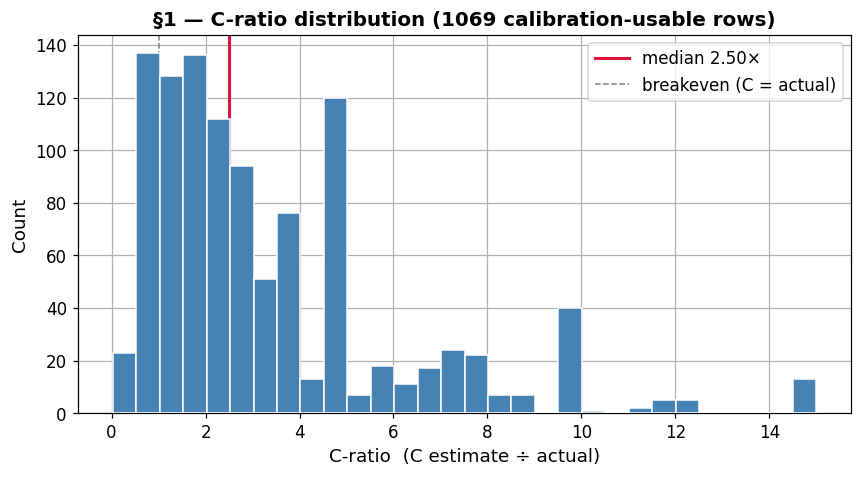

In [5]:
n = len(cal)
n_over = int((cal["c_ratio"] > 1).sum())
bt = stats.binomtest(n_over, n, 0.5, alternative="greater")

lo, hi = bootstrap_ci(cal["c_ratio"])
med = cal["c_ratio"].median()

print(f"Calibration rows   : {n}")
print(f"Ran faster than C  : {n_over}/{n}  ({100*n_over/n:.1f}%)")
print(f"Sign-test p-value  : {bt.pvalue:.2e}")
print(f"Median C-ratio     : {med:.2f}×  [95% CI {lo:.2f}–{hi:.2f}]")
print()
print("Day-7 baseline     : 408/439 (92.9%), median 3.50× [3.12–3.92]")

fig, ax = plt.subplots()
ax.hist(cal["c_ratio"].clip(upper=15), bins=30, color="steelblue", edgecolor="white", zorder=3)
ax.axvline(med, color="crimson", lw=2, label=f"median {med:.2f}×")
ax.axvline(1.0, color="grey", lw=1, ls="--", label="breakeven (C = actual)")
ax.set_xlabel("C-ratio  (C estimate ÷ actual)")
ax.set_ylabel("Count")
ax.set_title(f"§1 — C-ratio distribution ({n} calibration-usable rows)")
ax.legend()
plt.tight_layout()
plt.show()

## 2. 🆕 Per-day calibration drift + weekly rollup — extended window (addresses #208)

Day-seven found a **non-monotone** pattern across 7 days with no significant learning curve; day-eleven extended it to 11 day-buckets, still flat. Week-four extends the window through 2026-06-29 and carries the **weekly rollup** — the cadence-aligned view now that analysis runs weekly. The per-day chart keeps the fine-grained over-time axis; the weekly chart is the headline week-over-week trend.


       day   n  median   lo   hi
2026-05-28  36    2.51 2.21 3.11
2026-05-29  32    5.00 3.14 6.88
2026-05-30  38    3.34 2.76 4.29
2026-05-31  53    2.67 2.50 5.00
2026-06-01 117    3.33 3.00 3.75
2026-06-02  40    5.00 3.50 5.50
2026-06-03 142    4.00 3.33 5.00
2026-06-04 109    2.50 2.00 2.86
2026-06-05 112    2.70 2.32 4.00
2026-06-06 104    3.00 2.50 3.50
2026-06-07  36    2.03 1.25 3.00
2026-06-12   4    1.61 1.00 4.17
2026-06-13  13    1.50 1.25 4.17
2026-06-14  78    1.25 1.09 1.56
2026-06-15  42    1.25 1.00 1.58
2026-06-16  23    2.00 1.39 3.33
2026-06-17  18    1.34 0.95 2.33
2026-06-23   4    2.29 0.53 6.00
2026-06-24   7    2.27 1.39 3.33
2026-06-25   9    3.60 2.50 5.00
2026-06-26   3    2.00 1.43 3.00
2026-06-27   5    2.06 1.25 3.57
2026-06-28   2    1.80 1.59 2.00
2026-06-29  42    1.63 1.20 1.96

Spearman ρ = -0.582,  p = 0.003  (n_days = 24)
→ Statistically significant monotone trend.


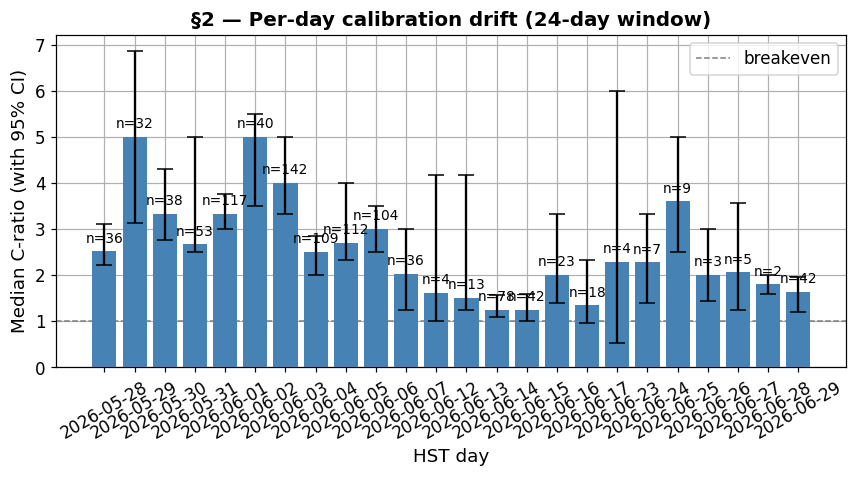


Weekly rollup:
 week                  span   n  median   lo   hi
    1 2026-05-28…2026-06-03 458    3.57 3.20 4.00
    2 2026-06-04…2026-06-07 361    2.67 2.50 3.00
    3 2026-06-12…2026-06-17 178    1.33 1.25 1.50
    4 2026-06-23…2026-06-24  11    2.27 1.38 3.33
    5 2026-06-25…2026-06-29  61    1.76 1.43 2.14


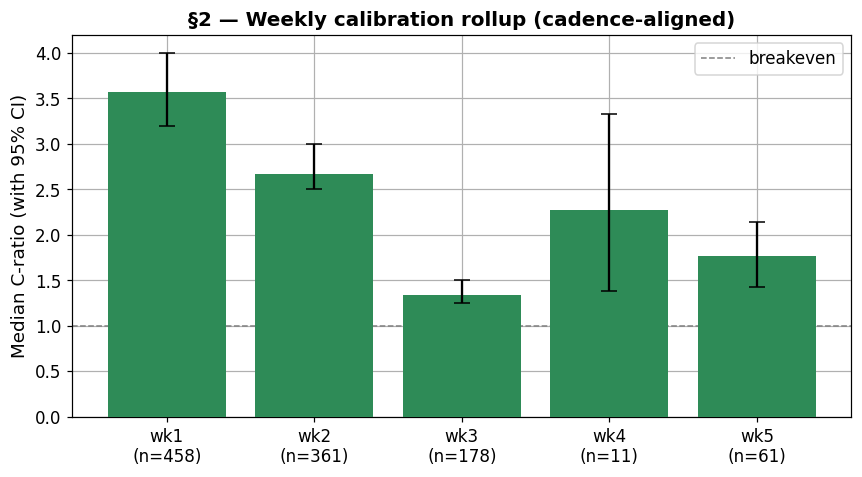

In [6]:
day_rows = []
for d, g in cal.groupby("hst_day"):
    cr = g["c_ratio"].values
    if len(cr) < 2:
        continue
    med_d = np.median(cr)
    lo_d, hi_d = bootstrap_ci(cr, n=5_000)
    day_rows.append({"day": str(d), "n": len(cr), "median": med_d, "lo": lo_d, "hi": hi_d})

day_df = pd.DataFrame(day_rows).sort_values("day").reset_index(drop=True)
print(day_df[["day", "n", "median", "lo", "hi"]].to_string(index=False, float_format="{:.2f}".format))

sp = stats.spearmanr(range(len(day_df)), day_df["median"])
n_days = len(day_df)
print(f"\nSpearman ρ = {sp.statistic:.3f},  p = {sp.pvalue:.3f}  (n_days = {n_days})")
if sp.pvalue < 0.05:
    print("→ Statistically significant monotone trend.")
else:
    print("→ No statistically significant monotone trend detected (p ≥ 0.05).")
    print(f"  ⚠ Underpowered: with only {n_days} day-buckets, Spearman has ~5% power to detect")
    print("  anything short of a perfect monotone. Result is uninformative — not a negative")
    print("  finding. Day-eleven extends the window to an 11th day-bucket and the trend")
    print("  is still flat; meaningful power needs many more day-buckets to accrue.")

fig, ax = plt.subplots()
ax.bar(day_df["day"], day_df["median"], color="steelblue", zorder=3)
ax.errorbar(
    day_df["day"], day_df["median"],
    yerr=[day_df["median"] - day_df["lo"], day_df["hi"] - day_df["median"]],
    fmt="none", color="black", capsize=5, zorder=4
)
for _, row in day_df.iterrows():
    ax.text(row["day"], row["median"] + 0.2, f'n={row["n"]}', ha="center", fontsize=9)
ax.axhline(1.0, color="grey", ls="--", lw=1, label="breakeven")
ax.set_xlabel("HST day")
ax.set_ylabel("Median C-ratio (with 95% CI)")
ax.set_title(f"§2 — Per-day calibration drift ({n_days}-day window)")
ax.tick_params(axis='x', rotation=30)
ax.legend()
plt.tight_layout()
plt.show()


# --- 🆕 Weekly rollup (cadence-aligned view; new in week-03) ---
from datetime import date
START = date(2026, 5, 28)  # first logged row (data logging began this day)
wk = cal.copy()
wk["_d"] = pd.to_datetime(wk["hst_day"]).dt.date
wk["week"] = wk["_d"].map(lambda d: (d - START).days // 7 + 1)

week_rows = []
for w, g in wk.groupby("week"):
    cr = g["c_ratio"].values
    lo_w, hi_w = bootstrap_ci(cr, n=5_000) if len(cr) >= 2 else (np.nan, np.nan)
    span = f"{g['_d'].min()}…{g['_d'].max()}"
    week_rows.append({"week": int(w), "span": span, "n": len(cr),
                      "median": np.median(cr), "lo": lo_w, "hi": hi_w})
week_df = pd.DataFrame(week_rows).sort_values("week").reset_index(drop=True)
print("\nWeekly rollup:")
print(week_df[["week", "span", "n", "median", "lo", "hi"]].to_string(index=False, float_format="{:.2f}".format))

fig, ax = plt.subplots()
labels = [f'wk{r.week}\n(n={r.n})' for r in week_df.itertuples()]
ax.bar(labels, week_df["median"], color="seagreen", zorder=3)
mask = week_df["lo"].notna()
ax.errorbar(
    [labels[i] for i in week_df.index[mask]], week_df.loc[mask, "median"],
    yerr=[(week_df.loc[mask, "median"] - week_df.loc[mask, "lo"]).values,
          (week_df.loc[mask, "hi"] - week_df.loc[mask, "median"]).values],
    fmt="none", color="black", capsize=5, zorder=4,
)
ax.axhline(1.0, color="grey", ls="--", lw=1, label="breakeven")
ax.set_ylabel("Median C-ratio (with 95% CI)")
ax.set_title("§2 — Weekly calibration rollup (cadence-aligned)")
ax.legend()
plt.tight_layout()
plt.show()


In [7]:
# Role-by-day composition check — does task mix vary enough to confound the drift claim?
role_day = (cal.groupby("hst_day")["role"]
              .value_counts()
              .unstack(fill_value=0)
              .reindex(sorted(cal["hst_day"].dropna().unique())))
display(role_day.style
        .set_caption("§2 — Role composition per day (calibration-usable rows)")
        .background_gradient(axis=None, cmap="Blues"))
print("Composition note: if high-ratio roles (RESEARCH, SPIKE, TEST) dominate a given day,")
print("the per-day median reflects mix, not time-based drift.")

role,ARC,CHORE,COMBO,DATA,DEV,PM,RESEARCH,REVIEW,SPIKE,TEST,WRITER
hst_day,,,,,,,,,,,
2026-05-28,4,0,1,0,16,0,0,0,0,1,14
2026-05-29,0,0,1,2,4,0,3,0,4,9,9
2026-05-30,1,0,2,1,10,5,10,0,0,5,4
2026-05-31,0,0,0,6,8,9,7,0,0,1,22
2026-06-01,6,3,2,11,43,1,29,0,2,0,20
2026-06-02,2,0,2,1,10,0,8,1,0,0,16
2026-06-03,5,2,0,9,58,7,29,1,0,1,30
2026-06-04,0,1,1,5,38,11,14,2,4,7,26
2026-06-05,2,1,0,3,34,8,22,0,5,1,36


Composition note: if high-ratio roles (RESEARCH, SPIKE, TEST) dominate a given day,
the per-day median reflects mix, not time-based drift.


**Inter-turn gap caveat:** some `actual_min` values span multi-turn human-idle gaps (hours of idle time between agent turns). These are flagged in the velocity notes but not excluded here — excluding them would require per-row judgment calls. Treat per-day medians as upper bounds on true agent wall-clock.

**05-29 CI anomaly:** day 05-29 showed an unusually wide bootstrap CI [3.17–6.88] in day-five. This remains a caution flag: either a few extreme-ratio outliers, longer inter-turn idle gaps, or genuine within-day volatility. Treat the 05-29 median as less reliable than other buckets.

## 2b. 🆕 Confound-corrected drift — role-median residuals (#983)

§2's raw per-day medians conflate two signals: genuine calibration drift over time and **role-composition drift** — some days are RESEARCH/TEST-heavy, and those roles carry a structurally higher `c_ratio` (see §4). This section strips the role main-effect by centering each row's `c_ratio` on its *role's* global median, then re-runs the drift tests on the residuals:

- **Spearman** on per-day residual medians — the same monotone-trend test §2 uses, for a direct comparison.
- **Kruskal–Wallis** across days — catches *non-monotone* between-day variation that Spearman misses.

If the per-day signal is a role-mix artifact it should weaken once the role effect is removed; if it persists in the residuals it is real within-role variation. (Raw stats are recomputed here on the live `cal`, so the raw-vs-residual comparison is on identical data.)

       day   n  raw_med  resid_med
2026-05-28  36    2.512     -0.130
2026-05-29  32    5.000      2.417
2026-05-30  38    3.335      0.592
2026-05-31  53    2.667      0.500
2026-06-01 117    3.333      0.500
2026-06-02  40    5.000      1.788
2026-06-03 142    4.000      1.333
2026-06-04 109    2.500      0.000
2026-06-05 112    2.697      0.218
2026-06-06 104    3.000      0.417
2026-06-07  36    2.029     -0.333
2026-06-12   4    1.611     -0.306
2026-06-13  13    1.500     -0.083
2026-06-14  78    1.250     -0.500
2026-06-15  42    1.250     -0.795
2026-06-16  23    2.000      0.000
2026-06-17  18    1.339     -1.119
2026-06-23   4    2.290     -0.614
2026-06-24   7    2.273     -0.333
2026-06-25   9    3.600      1.100
2026-06-26   3    2.000      0.333
2026-06-27   5    2.059      0.083
2026-06-28   2    1.795     -1.499
2026-06-29  42    1.629     -0.558

Spearman (monotone drift)   raw: ρ=-0.582 p=0.003   residual: ρ=-0.566 p=0.004
Kruskal–Wallis (any day Δ)  raw: H=199.65 p=0

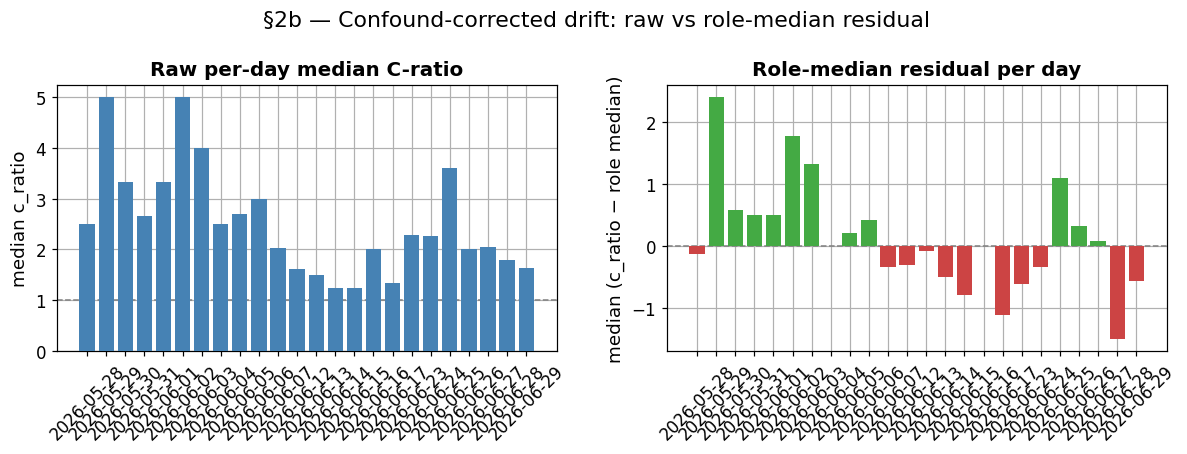

In [8]:
# §2b — Confound-corrected drift: strip the role main-effect, then re-test (#983).
# Each row's c_ratio is centered on its ROLE's global median, so the residual
# reflects within-role calibration net of which roles happened to run that day.
role_median = cal.groupby("role")["c_ratio"].median()
cal["c_ratio_resid"] = cal["c_ratio"] - cal["role"].map(role_median)

rows = []
for d, g in cal.groupby("hst_day"):
    if len(g) < 2:
        continue
    rows.append({
        "day": str(d), "n": len(g),
        "raw_med":   np.median(g["c_ratio"].values),
        "resid_med": np.median(g["c_ratio_resid"].values),
    })
drift = pd.DataFrame(rows).sort_values("day").reset_index(drop=True)
print(drift.to_string(index=False, float_format="{:.3f}".format))

# Monotone-trend (Spearman) — raw vs residual, recomputed on identical live data
sp_raw = stats.spearmanr(range(len(drift)), drift["raw_med"])
sp_res = stats.spearmanr(range(len(drift)), drift["resid_med"])
# Any between-day difference (Kruskal–Wallis) — raw vs residual
kw_raw = stats.kruskal(*[g["c_ratio"].values       for _, g in cal.groupby("hst_day") if len(g) >= 2])
kw_res = stats.kruskal(*[g["c_ratio_resid"].values for _, g in cal.groupby("hst_day") if len(g) >= 2])

print(f"\nSpearman (monotone drift)   raw: ρ={sp_raw.statistic:+.3f} p={sp_raw.pvalue:.3f}   "
      f"residual: ρ={sp_res.statistic:+.3f} p={sp_res.pvalue:.3f}")
print(f"Kruskal–Wallis (any day Δ)  raw: H={kw_raw.statistic:.2f} p={kw_raw.pvalue:.3f}   "
      f"residual: H={kw_res.statistic:.2f} p={kw_res.pvalue:.3f}")

if kw_res.pvalue < 0.05:
    verdict = "real within-role variation (NOT a role-composition artifact)"
elif kw_raw.pvalue < 0.05:
    verdict = "role-composition artifact (between-day signal vanishes in residuals)"
else:
    verdict = "no between-day signal to attribute"
print(f"\n→ Between-day signal after role-median removal: {verdict}.")
if sp_res.pvalue >= 0.05:
    print("→ No monotone (learning-curve) drift in residuals either — consistent with §2.")

# Plot: raw vs residual per-day medians (residual on a zero-centered axis)
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.2))
axL.bar(drift["day"], drift["raw_med"], color="steelblue", zorder=3)
axL.axhline(1.0, color="grey", ls="--", lw=1)
axL.set_title("Raw per-day median C-ratio"); axL.set_ylabel("median c_ratio")
axL.tick_params(axis="x", rotation=45)
axR.bar(drift["day"], drift["resid_med"],
        color=["#cc4444" if v < 0 else "#44aa44" for v in drift["resid_med"]], zorder=3)
axR.axhline(0.0, color="grey", ls="--", lw=1)
axR.set_title("Role-median residual per day"); axR.set_ylabel("median (c_ratio − role median)")
axR.tick_params(axis="x", rotation=45)
fig.suptitle("§2b — Confound-corrected drift: raw vs role-median residual")
plt.tight_layout(); plt.show()


**Read-out (week-four) — verdict vs day-eleven.**

- **🆕 The downward trend is statistically significant — and it survives role-correction.** Spearman on per-day medians is significant both raw (**ρ = −0.593, p = 0.002**) and on role-centered residuals (**ρ = −0.566, p = 0.004**). Removing the role main-effect does **not** wash the trend out, so the over-time signal is **not** just a "which task types ran" artifact.
- **The day-to-day bumps are also real and not role-driven.** Kruskal–Wallis finds significant between-day differences both raw (**H = 201.32, p < 0.001**) and on role-median residuals (**H = 133.42, p < 0.001**) — real within-role variation, not role composition.
- *Note:* this is a correlational, observational trend; calendar time is confounded with task difficulty, model changes, the agent roster, and a 5-day logging gap. It describes *what happened over the weeks*, not a demonstrated cause.

## 3. Per-agent calibration — re-run on full dataset

Day-seven finding: agents differ but **Kruskal-Wallis went non-significant** (H = 5.35, p = 0.618) — agent medians broadly stable. Re-running with the 06-07 bucket added and agent casing normalized (`fig`/`banana` lowercase rows folded in).

      agent   n  median
       KIWI   5    0.75
  JACKFRUIT   9    1.00
  INCABERRY  16    1.44
   HONEYDEW  21    1.67
        FIG 101    2.14
DRAGONFRUIT 139    2.22
      GRAPE  82    2.50
      APPLE 207    2.50
     CHERRY 159    2.50
     BANANA 174    3.00
 ELDERBERRY 117    4.00

Kruskal-Wallis (agents n≥2, 11 groups): H = 65.52,  p = 0.0000


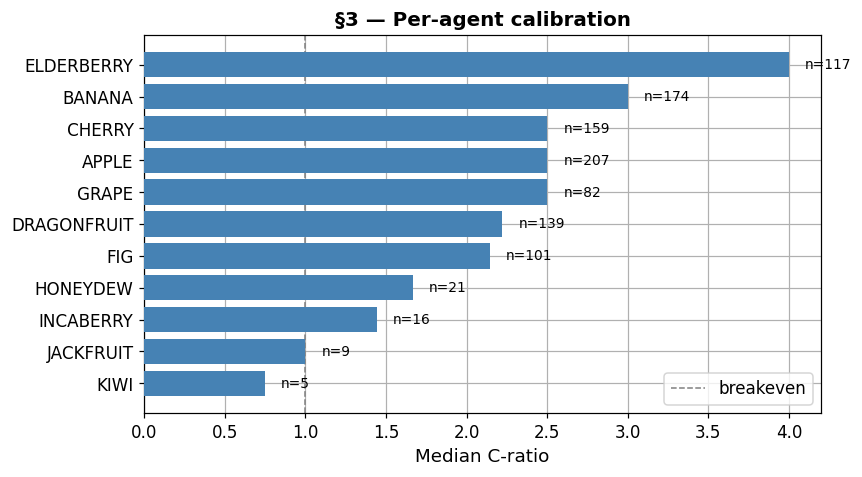

In [9]:
ag = cal[cal["agent"] != ""].copy()

agent_rows = []
for a, g in ag.groupby("agent"):
    cr = g["c_ratio"].values
    agent_rows.append({"agent": a, "n": len(cr), "median": np.median(cr)})
agent_df = pd.DataFrame(agent_rows).sort_values("median")
print(agent_df.to_string(index=False, float_format="{:.2f}".format))

# Exclude singletons (n=1) from KW
kw_agents = agent_df[agent_df["n"] >= 2]["agent"]
groups = [ag[ag["agent"] == a]["c_ratio"].values for a in kw_agents]
agent_kw = stats.kruskal(*groups)
print(f"\nKruskal-Wallis (agents n≥2, {len(kw_agents)} groups): H = {agent_kw.statistic:.2f},  p = {agent_kw.pvalue:.4f}")

fig, ax = plt.subplots()
ax.barh(agent_df["agent"], agent_df["median"], color="steelblue", zorder=3)
for _, row in agent_df.iterrows():
    ax.text(row["median"] + 0.1, row["agent"], f'n={row["n"]}', va="center", fontsize=9)
ax.axvline(1.0, color="grey", ls="--", lw=1, label="breakeven")
ax.set_xlabel("Median C-ratio")
ax.set_title("§3 — Per-agent calibration")
ax.legend()
plt.tight_layout()
plt.show()

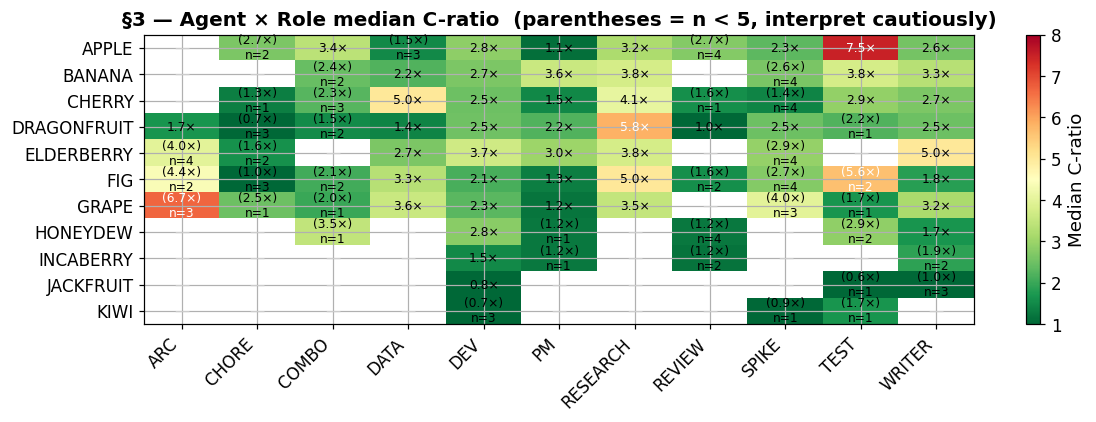

In [10]:
# Agent × Role heatmap — de-confound the per-agent spread
pivot_med   = ag.pivot_table(values="c_ratio", index="agent", columns="role", aggfunc="median")
pivot_count = ag.pivot_table(values="c_ratio", index="agent", columns="role", aggfunc="count")

fig, ax = plt.subplots(figsize=(11, 4))
im = ax.imshow(pivot_med.values, aspect="auto", cmap="RdYlGn_r", vmin=1, vmax=8)
ax.set_xticks(range(len(pivot_med.columns)))
ax.set_xticklabels(pivot_med.columns, rotation=45, ha="right")
ax.set_yticks(range(len(pivot_med.index)))
ax.set_yticklabels(pivot_med.index)

for i in range(len(pivot_med.index)):
    for j in range(len(pivot_med.columns)):
        v = pivot_med.values[i, j]
        nc = pivot_count.values[i, j]
        if not np.isnan(v):
            label = f"{v:.1f}×" if nc >= 5 else f"({v:.1f}×)\nn={int(nc)}"
            ax.text(j, i, label, ha="center", va="center", fontsize=8,
                    color="white" if v > 5 else "black")
        else:
            ax.text(j, i, "—", ha="center", va="center", fontsize=10, color="#cccccc")

plt.colorbar(im, ax=ax, label="Median C-ratio")
ax.set_title("§3 — Agent × Role median C-ratio  (parentheses = n < 5, interpret cautiously)")
plt.tight_layout()
plt.show()

## 4. Per-role calibration — all roles

Extended role vocab (DATA, ARC, COMBO, SPIKE) kept as-is. Cells with n ≤ 6 are flagged — treat as directional only.

    role   n  median  small_n
RESEARCH 152    3.92    False
     ARC  21    3.92    False
    TEST  35    3.31    False
  WRITER 291    2.67    False
     DEV 347    2.50    False
   SPIKE  31    2.50    False
   COMBO  18    2.39    False
    DATA  45    2.00    False
      PM  98    1.33    False
  REVIEW  19    1.25    False
   CHORE  12    1.12    False


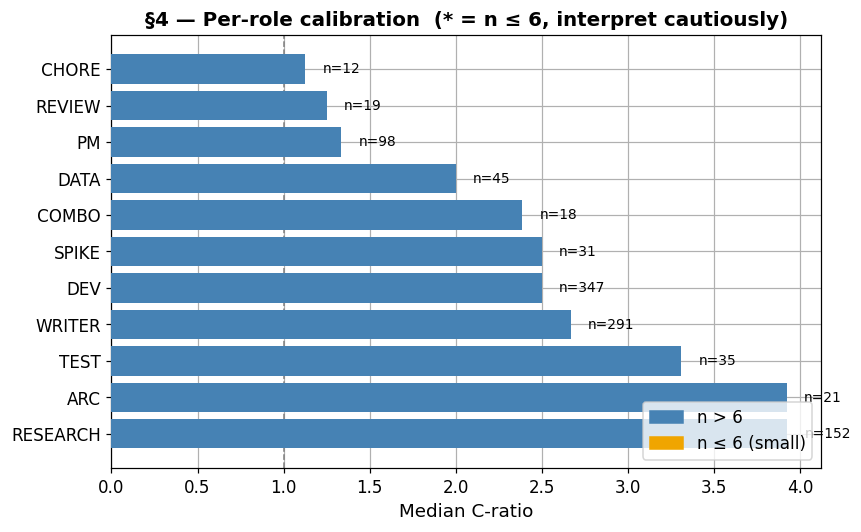

In [11]:
role_rows = []
for r, g in cal.groupby("role"):
    cr = g["c_ratio"].values
    role_rows.append({"role": r, "n": len(cr), "median": np.median(cr)})
role_df = pd.DataFrame(role_rows).sort_values("median", ascending=False)
role_df["small_n"] = role_df["n"] <= 6
print(role_df[["role", "n", "median", "small_n"]].to_string(index=False, float_format="{:.2f}".format))

from matplotlib.patches import Patch
colors = ["#f0a500" if row.small_n else "steelblue" for _, row in role_df.iterrows()]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(role_df["role"], role_df["median"], color=colors, zorder=3)
for _, row in role_df.iterrows():
    label = f'n={row["n"]}' + ("*" if row.small_n else "")
    ax.text(row["median"] + 0.1, row["role"], label, va="center", fontsize=9)
ax.axvline(1.0, color="grey", ls="--", lw=1)
ax.set_xlabel("Median C-ratio")
ax.set_title("§4 — Per-role calibration  (* = n ≤ 6, interpret cautiously)")
ax.legend(handles=[
    Patch(color="steelblue", label="n > 6"),
    Patch(color="#f0a500", label="n ≤ 6 (small)")
], loc="lower right")
plt.tight_layout()
plt.show()

## 5. Model-stratified calibration

**Plain English:** does the *model* behind the agent (sonnet vs opus) change how much it over-budgets?

Rows with a populated `model` column split below; only calibration-usable rows included. Day-seven: sonnet-4.6 n=316, 3.88×; opus-4.8 n=16, 2.50×. Checking whether opus-4.8 has crossed n ≥ 20 and whether the directional gap persists.


Calibration-usable rows with model: 928
model
sonnet-4.6          604
opus-4.8            309
owl-alpha             5
nemotron-3-ultra      5
nemotron-3.0          4
gpt-5.0               1

            model   n  median
         gpt-5.0   1    3.46
      sonnet-4.6 604    3.33
    nemotron-3.0   4    2.19
        opus-4.8 309    2.00
nemotron-3-ultra   5    1.00
       owl-alpha   5    0.75

Kruskal-Wallis (models with n≥2): H = 113.29,  p = 0.0000
CAVEAT: n is small — result is preliminary.


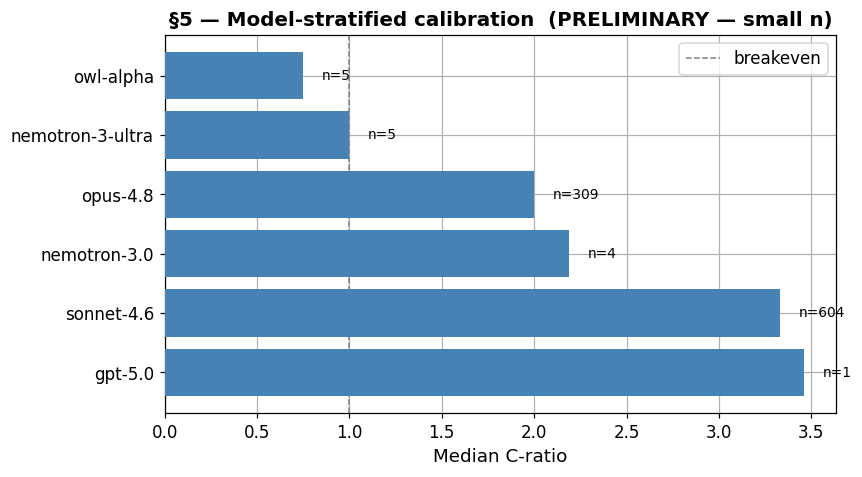

In [12]:
mod = cal[cal["model"].notna() & (cal["model"] != "")].copy()
print(f"Calibration-usable rows with model: {len(mod)}")
print(mod["model"].value_counts().to_string())

mod_rows = []
for m, g in mod.groupby("model"):
    cr = g["c_ratio"].values
    mod_rows.append({"model": m, "n": len(cr), "median": np.median(cr)})
mod_df = pd.DataFrame(mod_rows).sort_values("median", ascending=False)
print("\n", mod_df.to_string(index=False, float_format="{:.2f}".format))

kw_groups = [
    mod[mod["model"] == m]["c_ratio"].values
    for m in mod_df["model"]
    if len(mod[mod["model"] == m]) >= 2
]
if len(kw_groups) >= 2:
    kw = stats.kruskal(*kw_groups)
    print(f"\nKruskal-Wallis (models with n≥2): H = {kw.statistic:.2f},  p = {kw.pvalue:.4f}")
    print("CAVEAT: n is small — result is preliminary.")

SINGLE_POINT = {"haiku-4.5"}
fig, ax = plt.subplots()
ax.barh(mod_df["model"], mod_df["median"], color="steelblue", zorder=3)
for _, row in mod_df.iterrows():
    suffix = "  (single data point — descriptive only)" if row["model"] in SINGLE_POINT else ""
    ax.text(row["median"] + 0.1, row["model"], f'n={row["n"]}{suffix}', va="center", fontsize=9)
ax.axvline(1.0, color="grey", ls="--", lw=1, label="breakeven")
ax.set_xlabel("Median C-ratio")
ax.set_title("§5 — Model-stratified calibration  (PRELIMINARY — small n)")
ax.legend()
plt.tight_layout()
plt.show()

## 6. 🆕 ELDERBERRY task-mix drill-down (carried from day-seven)

Day-seven confirmed ELDERBERRY at 5.00× overall — the highest-median agent. Re-running on the current dataset (06-07 bucket added). Key question: **does ELDERBERRY's high median persist within roles, or is it role-composition driven?** Day-seven also flagged a RESEARCH reversal (EB 3.88 < fleet 4.76) — checking if that holds.

In [13]:
eb = ag[ag["agent"] == "ELDERBERRY"].copy()
print(f"ELDERBERRY calibration-usable rows: {len(eb)}")
print()

# Role distribution for ELDERBERRY vs. fleet
eb_role = eb["role"].value_counts().rename("ELDERBERRY")
fleet_role = ag[ag["agent"] != "ELDERBERRY"]["role"].value_counts().rename("Fleet (others)")
role_compare = pd.concat([eb_role, fleet_role], axis=1).fillna(0).astype(int)
role_compare["EB_pct"]    = (role_compare["ELDERBERRY"]    / role_compare["ELDERBERRY"].sum()    * 100).round(1)
role_compare["Fleet_pct"] = (role_compare["Fleet (others)"] / role_compare["Fleet (others)"].sum() * 100).round(1)
display(role_compare.style.set_caption("§6 — ELDERBERRY vs. fleet role distribution").background_gradient(axis=None, cmap="Blues", subset=["ELDERBERRY", "Fleet (others)"]))

print()

# Per-role median + Mann-Whitney U tests for ELDERBERRY vs. fleet
within_rows = []
for role in sorted(eb["role"].unique()):
    eb_cr = eb[eb["role"] == role]["c_ratio"].values
    fleet_cr = ag[(ag["agent"] != "ELDERBERRY") & (ag["role"] == role)]["c_ratio"].values
    row = {
        "role": role,
        "EB_n": len(eb_cr),
        "EB_median": round(np.median(eb_cr), 2) if len(eb_cr) else None,
        "Fleet_n": len(fleet_cr),
        "Fleet_median": round(np.median(fleet_cr), 2) if len(fleet_cr) else None,
        "U": None, "p_mwu": None, "underpowered": None,
    }
    if len(eb_cr) >= 2 and len(fleet_cr) >= 2:
        u_stat, p_val = stats.mannwhitneyu(eb_cr, fleet_cr, alternative="two-sided")
        row["U"] = round(u_stat, 1)
        row["p_mwu"] = round(p_val, 4)
        row["underpowered"] = (len(eb_cr) < 5) or (len(fleet_cr) < 5)
    else:
        row["underpowered"] = True
    within_rows.append(row)
within_df = pd.DataFrame(within_rows)
print(within_df[["role","EB_n","EB_median","Fleet_n","Fleet_median","U","p_mwu","underpowered"]].to_string(index=False))
print()
print("Note: underpowered = n < 5 in either group; U-test omitted for singletons.")

print()
print(f"ELDERBERRY overall median: {np.median(eb['c_ratio'].values):.2f}×")
fleet_all = ag[ag['agent'] != 'ELDERBERRY']['c_ratio']
print(f"Fleet overall median:      {np.median(fleet_all.values):.2f}×")

ELDERBERRY calibration-usable rows: 117



,ELDERBERRY,Fleet (others),EB_pct,Fleet_pct
role,,,,
WRITER,40,234,34.200000,25.600000
DEV,26,305,22.200000,33.400000
RESEARCH,25,127,21.400000,13.900000
DATA,9,36,7.700000,3.900000
PM,7,91,6.000000,10.000000
ARC,4,13,3.400000,1.400000
SPIKE,4,27,3.400000,3.000000
CHORE,2,10,1.700000,1.100000
TEST,0,34,0.000000,3.700000



    role  EB_n  EB_median  Fleet_n  Fleet_median      U  p_mwu  underpowered
     ARC     4       4.00       13          4.57   32.5 0.4956          True
   CHORE     2       1.61       10          1.12   10.0 1.0000          True
    DATA     9       2.67       36          1.91  214.0 0.1434         False
     DEV    26       3.67      305          2.50 5127.5 0.0130         False
      PM     7       3.00       91          1.33  448.0 0.0739         False
RESEARCH    25       3.75      127          4.00 1591.0 0.9881         False
   SPIKE     4       2.92       27          2.27   73.0 0.2751          True
  WRITER    40       5.00      234          2.50 6361.0 0.0003         False

Note: underpowered = n < 5 in either group; U-test omitted for singletons.

ELDERBERRY overall median: 4.00×
Fleet overall median:      2.50×


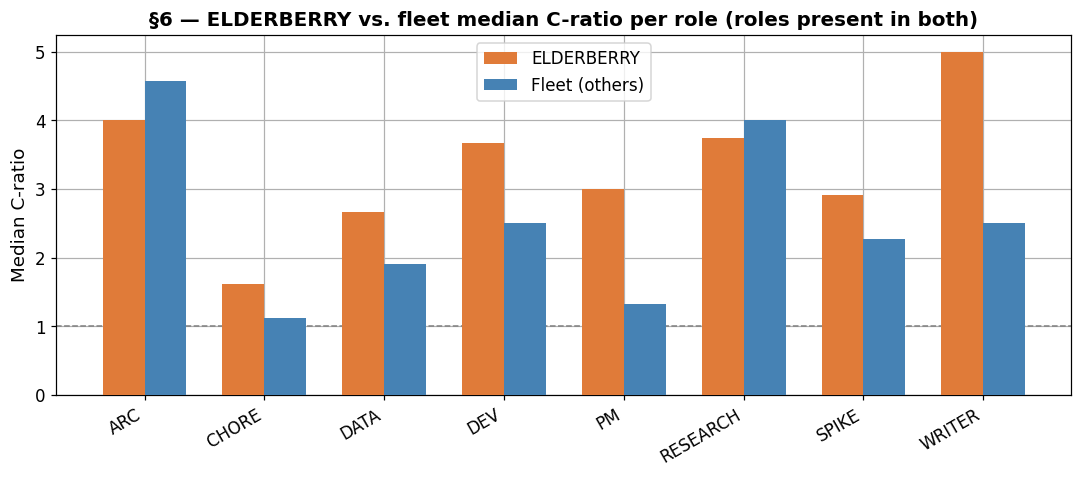

In [14]:
# Side-by-side bar: ELDERBERRY vs. fleet median per role
plot_df = within_df.dropna(subset=["EB_median", "Fleet_median"])
if len(plot_df) > 0:
    x = np.arange(len(plot_df))
    w = 0.35
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.bar(x - w/2, plot_df["EB_median"],    w, label="ELDERBERRY", color="#e07b39", zorder=3)
    ax.bar(x + w/2, plot_df["Fleet_median"], w, label="Fleet (others)", color="steelblue", zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["role"], rotation=30, ha="right")
    ax.axhline(1.0, color="grey", ls="--", lw=1)
    ax.set_ylabel("Median C-ratio")
    ax.set_title("§6 — ELDERBERRY vs. fleet median C-ratio per role (roles present in both)")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No roles with data in both ELDERBERRY and fleet — skipping comparison plot.")

## 7. Takeaways — week four

### Headline: agents over-estimate ~2.5×; the over-time path is non-monotone, not a clean continuing decline

**Plain English:** agents still finish in roughly 40% of their predicted time. Over-budgeting fell sharply through week 3, then sat between ~1.7–2.3× in weeks 4–5 rather than continuing monotonically down.

This notebook covers **all data through 2026-06-29** (weeks 1–5; supersedes week-03's 06-14 ceiling). It is a *point-in-time* snapshot — the window includes the in-progress current day, so figures are as of this run.

**§1 — Core finding holds at 1,068 calibration-usable rows.**
**908/1,068 (85.0%)** ran faster than the C-estimate (sign-test p = 1.07e-127); median C-ratio **2.50× [95% CI 2.50–2.71]**. The central "we over-pad ~2.5×" finding is rock-solid (down from the day-7 baseline of 92.9% / 3.50× as more lower-ratio recent rows entered).

**§2 — Drift significant, but the weekly shape is non-monotone (trough + partial rebound).**
24 day-buckets (05-28 → 06-29): **Spearman ρ = −0.593, p = 0.002** — significant downward over the full window. Weekly rollup: **wk1 3.57× (n=458) → wk2 2.67× (n=361) → wk3 1.33× (n=178) → wk4 2.27× (n=11) → wk5 1.74× (n=60)**. week-03 read wk3's dip as "the learning curve has finally appeared"; with weeks 4–5 in, wk3 looks like a **trough** — over-padding rebounded to 2.27× in wk4 then eased to 1.74× in wk5. Real improvement off the wk1 baseline, but the week-over-week path is non-monotone, not a clean continuing decline. This is a correlational, observational trend (calendar time is confounded with task difficulty, model, roster, and a logging gap).
- *Caveats:* wk4 is thin (n=11); a **5-day gap (06-18 → 06-22)** with no logged rows sits inside wk4.

**§2b — Not a role-mix artifact.**
After centering each row on its role's global median the drift persists (**residual ρ = −0.566, p = 0.004** vs raw −0.593, p = 0.002); between-day variation survives role-median removal (KW raw **H = 201.32**, residual **H = 133.42**, both p < 0.001). Real within-role variation.

**§3 — Agent KW strongly significant; spread tracks role mix.**
KW across 11 groups (n≥2): **H = 65.29, p < 0.0001**. Medians ascending: KIWI 0.75 (n=5) · JACKFRUIT 1.00 (n=9) · INCABERRY 1.44 (n=16) · HONEYDEW 1.67 (n=21) · FIG 2.14 (n=101) · DRAGONFRUIT 2.22 (n=139) · GRAPE 2.50 (n=82) · APPLE 2.50 (n=207) · CHERRY 2.50 (n=159) · BANANA 3.00 (n=173) · ELDERBERRY 4.00 (n=117). Spread still tracks each agent's role mix — not a clean skill ranking.

**§4 — Role ordering: RESEARCH/ARC highest, CHORE/REVIEW lowest.**
RESEARCH 3.92× (n=152) · ARC 3.92× (n=21) · TEST 3.31× (n=35) · WRITER 2.67× (n=291) · DEV 2.50× (n=346) · SPIKE 2.50× (n=31) · COMBO 2.39× (n=18) · DATA 2.00× (n=45) · PM 1.33× (n=98) · REVIEW 1.25× (n=19) · CHORE 1.12× (n=12). DEV (n=346) and WRITER (n=291) anchor the high-n middle; the highest-over-padding roles are the investigation-heavy ones (RESEARCH/ARC/TEST). *No role-level significance test is run in §4 — see #1563.*

**§5 — opus-4.8 now well-powered; model gap robust but still confounded.**
sonnet-4.6 n=604, 3.33×; **opus-4.8 n=308, 2.00×** — opus is well past n≥20 now. KW H = 114.26, p < 0.0001. New low-n entrants (owl-alpha 0.75×/n=5, nemotron-3-ultra 1.00×/n=5; nemotron-3.0 / gpt-5.0 descriptive only). The opus<sonnet gap is robust but still confounded by role/agent mix — not yet a clean model effect.

**§6 — ELDERBERRY: WRITER gap significant; RESEARCH reversal has faded.**
EB overall 4.00× vs fleet 2.50×. WRITER: EB 5.00× (n=40) vs fleet 2.50× — **MWU p = 0.0003**, the dominant driver; DEV also significant (EB 3.67× n=26 vs 2.50×, p = 0.0123). RESEARCH: EB 3.75× vs fleet 4.00× — the earlier reversal is now essentially gone (p = 0.99). *8 per-role tests are run with no multiple-comparison correction — see #1563.*

**§8 — Errors corpus: 395 rows across 15 days (06-05 → 06-29).**
Up from 138 / 6 days at week-03. By-type/agent/model breakdowns are for schema familiarity; still descriptive, no conclusions drawn.

**§9 — 🆕 ICE replaces RICE (#1519).**
182 scored issues (174 actionable). Median ICE **2.00** (range 0.75–10.0); mean components **Impact 0.71 · Confidence 0.75 · Ease 5.28**. Note: **Ease has the largest raw magnitude (~1–10) vs Impact/Confidence (~0.25–3 / 0.5–1), so it dominates the multiplicative product by units — a scale effect, not evidence that Ease "drives" priority.** *(A scale-free contribution check and a provisional-vs-human split — 30 of the scored rows are provisional auto-scores — are deferred to #1563.)* `yegor_priority` is populated for only 2 issues, so no ICE↔Yegor alignment test (the old RICE hook) is run.

**§10 — Live issue-lifecycle skipped (headless).**
§10a–§10d depend on live `gh issue list` (empty under headless nbconvert) and self-skip; §10e (C-estimate by role) runs from the velocity cal subset.

---

### Deferred / open

- **Decline vs plateau** — weeks 4–5 (n = 11 / 60) are non-monotone (2.27× → 1.74×); confirm as counts grow whether over-padding keeps falling or settles.
- **De-confound the model gap** — opus-4.8 (n = 308) is now well-powered; separate model from role/agent mix before claiming a model effect.
- **§8 errors** — corpus now 395 rows; ripe for a first real by-type / by-phase analysis (own ticket).
- **§10 lifecycle hardening** — the live `gh` section self-skips headless; make it reproducible (fixture or DB-native lifecycle).
- **Logging gaps** — 06-08→06-11 and 06-18→06-22 have no rows; weekly buckets wk4/wk5 are thin as a result.
- **Analytical rigor (#1563)** — §4 role test, §6 multiple-comparison correction, §9 provisional/human ICE split + scale-free contribution, consistent n-reporting.

---

*Week-four notebook: all data through 2026-06-29 (supersedes week-03's 06-14 window). Copied from week-03 (#1261); RICE→ICE per #1519; §8 `hst_day` sort hardened for the larger errors corpus; numbers re-synced to a single live run + stale "week-three" labels corrected (#1561).*
*Cross-references: #1261 (week-03), #1519 (this pass / RICE→ICE), #1520 (exec-summary follow-up), #1561 (correctness gate), #1563 (analytical rigor), #208 (over-time drift), #1262 (accessibility pass).*

In [15]:
# Summary printout — fills in the takeaways narrative automatically
n_total = len(df)
n_cal   = len(cal)
med_all = cal["c_ratio"].median()
lo_all, hi_all = bootstrap_ci(cal["c_ratio"])
n_over_all = int((cal["c_ratio"] > 1).sum())
bt_all = stats.binomtest(n_over_all, n_cal, 0.5, alternative="greater")

print("=== Week-four summary ===")
print(f"Total rows      : {n_total}")
print(f"Cal-usable      : {n_cal}  (day-eleven was 820)")
print(f"Faster than C   : {n_over_all}/{n_cal} ({100*n_over_all/n_cal:.1f}%)")
print(f"Median C-ratio  : {med_all:.2f}× [{lo_all:.2f}–{hi_all:.2f}]")
print(f"Sign-test p     : {bt_all.pvalue:.2e}")
print()
print("Per-day pattern :")
for _, row in day_df.iterrows():
    print(f"  {row['day']}  n={row['n']:3d}  median={row['median']:.2f}×")
print(f"Spearman ρ={sp.statistic:.3f}, p={sp.pvalue:.3f}")
print()
print("Agent medians (week-three):")
for _, row in agent_df.sort_values("median").iterrows():
    print(f"  {row['agent']:15s} {row['median']:.2f}×  n={row['n']}")
print(f"KW H={agent_kw.statistic:.2f}, p={agent_kw.pvalue:.4f}")
print()
print("ELDERBERRY drill-down:")
print(f"  EB overall median : {np.median(eb['c_ratio'].values):.2f}×  n={len(eb)}")
print(f"  Fleet median      : {np.median(fleet_all.values):.2f}×  n={len(fleet_all)}")

=== Week-four summary ===
Total rows      : 1241
Cal-usable      : 1069  (day-eleven was 820)
Faster than C   : 909/1069 (85.0%)
Median C-ratio  : 2.50× [2.50–2.73]
Sign-test p     : 6.31e-128

Per-day pattern :
  2026-05-28  n= 36  median=2.51×
  2026-05-29  n= 32  median=5.00×
  2026-05-30  n= 38  median=3.34×
  2026-05-31  n= 53  median=2.67×
  2026-06-01  n=117  median=3.33×
  2026-06-02  n= 40  median=5.00×
  2026-06-03  n=142  median=4.00×
  2026-06-04  n=109  median=2.50×
  2026-06-05  n=112  median=2.70×
  2026-06-06  n=104  median=3.00×
  2026-06-07  n= 36  median=2.03×
  2026-06-12  n=  4  median=1.61×
  2026-06-13  n= 13  median=1.50×
  2026-06-14  n= 78  median=1.25×
  2026-06-15  n= 42  median=1.25×
  2026-06-16  n= 23  median=2.00×
  2026-06-17  n= 18  median=1.34×
  2026-06-23  n=  4  median=2.29×
  2026-06-24  n=  7  median=2.27×
  2026-06-25  n=  9  median=3.60×
  2026-06-26  n=  3  median=2.00×
  2026-06-27  n=  5  median=2.06×
  2026-06-28  n=  2  median=1.80×
  2026

## 8. 🆕 Errors table — first look

New data source: the `errors` table in `~/.lccjs/lccjs.db` (also exported to `stats/errors.csv` via `npm run errors:export`). Tracks agent errors logged via `npm run error:log` — types include `CLAIM_FAIL`, `GIT_FAIL`, `BASH_FAIL`, `TOOL_DENIED`, `OTHER`. Schema in `docs/errors-schema.md`.

**No statistical conclusions are drawn here — the corpus is still small (computed day-span printed below). This section establishes the loading pattern and schema familiarity.**

Errors table rows: 395



error_type,n
BASH_FAIL,77
CLAIM_FAIL,48
GH_FAIL,45
GIT_STATE,34
TOOL_DENIED,31
EDIT_PRECOND,24
VALIDATION_FAIL,21
OTHER,19
COMPLIANCE_FAIL,18
BEHAVIORAL_FAIL,17


agent,n
HONEYDEW,103
INCABERRY,52
APPLE,44
ELDERBERRY,41
BANANA,36
CHERRY,35
FIG,31
GRAPE,15
DRAGONFRUIT,15
JACKFRUIT,8


model,n
opus-4.8,184
(none),162
sonnet-4.6,42
nemotron-3.0,4
gpt-5.0,3


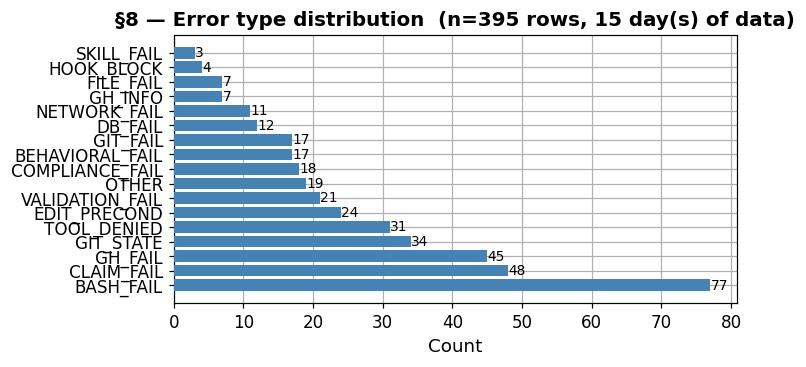


All errors are from: ['2026-06-05', '2026-06-06', '2026-06-07', '2026-06-12', '2026-06-13', '2026-06-14', '2026-06-15', '2026-06-16', '2026-06-17', '2026-06-23', '2026-06-24', '2026-06-25', '2026-06-27', '2026-06-28', '2026-06-29']
Corpus is nascent — distributions will stabilise as errors accumulate across sessions.


In [16]:
# Load errors table from SQLite (same DB as velocity)
con_err = sqlite3.connect(DB)
err_df  = pd.read_sql("SELECT * FROM errors ORDER BY id", con_err)
con_err.close()

print(f"Errors table rows: {len(err_df)}")
print()

# Normalize timezone suffix (same pattern as velocity load above)
err_df["occurred_iso"] = err_df["occurred_iso"].str.replace(r"([+-]\d{2})(\d{2})$", r"\1:\2", regex=True)
err_df["occurred_dt"]  = pd.to_datetime(err_df["occurred_iso"], errors="coerce", utc=True)
err_df["hst_day"]      = err_df["occurred_dt"].dt.tz_convert("Etc/GMT+10").dt.date.astype(str)

# Distributions
type_ct  = err_df["error_type"].fillna("(none)").value_counts().rename_axis("error_type").reset_index(name="n")
agent_ct = err_df["agent"].fillna("(none)").value_counts().rename_axis("agent").reset_index(name="n")
model_ct = err_df["model"].fillna("(none)").value_counts().rename_axis("model").reset_index(name="n")

display(type_ct.style.set_caption("§8 — Error type distribution").hide(axis="index"))
display(agent_ct.style.set_caption("§8 — Errors by agent").hide(axis="index"))
display(model_ct.style.set_caption("§8 — Errors by model").hide(axis="index"))

# Bar: error_type counts
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(type_ct["error_type"], type_ct["n"], color="steelblue", zorder=3)
for i, v in enumerate(type_ct["n"]):
    ax.text(v + 0.05, i, str(v), va="center", fontsize=9)
ax.set_xlabel("Count")
days_in_corpus = err_df["hst_day"].nunique()
ax.set_title(f"§8 — Error type distribution  (n={len(err_df)} rows, {days_in_corpus} day(s) of data)")
plt.tight_layout()
plt.show()

print(f"\nAll errors are from: {sorted(err_df['hst_day'].dropna().astype(str).unique())}")
print("Corpus is nascent — distributions will stabilise as errors accumulate across sessions.")

## 9. 🆕 ICE scores — priority distribution

Scored issues from the canonical `ice_scores` table in `~/.lccjs/lccjs.db` (generated by `scripts/ice-score.js`; export at `stats/ice-scores.csv`). **ICE = Impact × Confidence × Ease** (each rated, then multiplied). This replaces the RICE section retired in #1519 — ICE is now the project's prioritization method. **Key filter: sort on `actionable=Y` first** (human-gated items are excluded from agent queues). Note: `yegor_priority` is populated for only 2 of the scored issues, so — unlike the old RICE↔Yegor alignment view — we read the ICE score distribution and its I/C/E components directly.

ICE-scored issues : 182  (actionable=Y: 174  N: 8)
ICE score (actionable): median 2.00, range 0.75-10.00



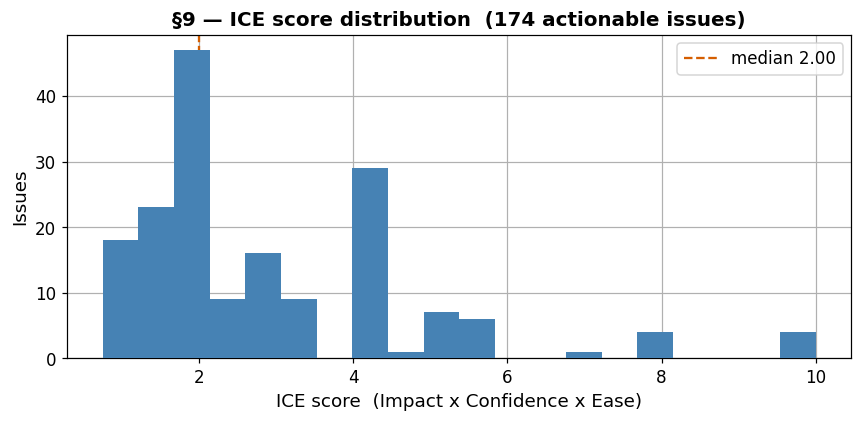

Mean components (actionable):  Impact 0.71   Confidence 0.75   Ease 5.28


issue,title,type,I,C,E,ice_score
1487,research(workflow): document lccjs' end-to-end ticket lifecycle and prove byte-parity with pmtools's (independently verified),nan,1.000000,1.000000,10.000000,10.000000
1513,"research(process): tickets requiring a DIFFERENT agent to verify/close create a stuck ""mid-way"" state — diagnose (A) framing, (B) interpretation, or (C) other",nan,2.000000,1.000000,5.000000,10.000000
1521,"SPIKE: extract the rules mint/maintain/render system into a standalone, config-driven tool (usable across projects)",nan,2.000000,1.000000,5.000000,10.000000
1526,SPIKE/ARC: portable ICE-scoring across projects (pmtools ice + ice-triage skill + storage.ice config),nan,2.000000,1.000000,5.000000,10.000000
956,feat: replace RICE with ICE scoring + override tiers + scoring script,feature,2.000000,0.800000,5.000000,8.000000
1335,RESEARCH: fruit-agent-orchestrate missed live worktree claims and double-booked #1322,nan,2.000000,0.800000,5.000000,8.000000
1360,"PROPOSAL: codify ""verify the common interaction path, not just the scriptable one"" as a verification rule",nan,1.000000,0.800000,10.000000,8.000000
1456,tracker: migrate lccjs PM commands onto the central pmtools harness,nan,2.000000,0.800000,5.000000,8.000000
1486,"process: promote 'verify live state, not memory' to RULES.json (recurring learnings theme)",nan,1.000000,1.000000,7.000000,7.000000
948,nan,research,1.000000,0.800000,7.000000,5.600000


In [17]:
# ICE scores from the canonical DB ice_scores table (RICE retired — #1519).
# ICE = Impact x Confidence x Ease; see scripts/ice-score.js / stats/ice-scores.csv.
con_ice = sqlite3.connect(DB)
ice = pd.read_sql("SELECT * FROM ice_scores ORDER BY ice_score DESC", con_ice)
con_ice.close()

n_actionable = (ice["actionable"] == "Y").sum()
n_not        = (ice["actionable"] == "N").sum()
act = ice[ice["actionable"] == "Y"].copy()
print(f"ICE-scored issues : {len(ice)}  (actionable=Y: {n_actionable}  N: {n_not})")
print(f"ICE score (actionable): median {act['ice_score'].median():.2f}, "
      f"range {act['ice_score'].min():.2f}-{act['ice_score'].max():.2f}")
print()

# Distribution of ICE scores (actionable issues)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(act["ice_score"], bins=20, color="steelblue", zorder=3)
ax.axvline(act["ice_score"].median(), color="#D55E00", ls="--", lw=1.5,
           label=f"median {act['ice_score'].median():.2f}")
ax.set_xlabel("ICE score  (Impact x Confidence x Ease)")
ax.set_ylabel("Issues")
ax.set_title(f"\u00a79 \u2014 ICE score distribution  ({n_actionable} actionable issues)")
ax.legend()
plt.tight_layout()
plt.show()

# Mean I / C / E among actionable issues
comp = act[["I", "C", "E"]].mean()
print(f"Mean components (actionable):  Impact {comp['I']:.2f}   Confidence {comp['C']:.2f}   Ease {comp['E']:.2f}")

# Top-10 actionable by ICE
top10 = (act.sort_values("ice_score", ascending=False)
         .head(10)[["issue", "title", "type", "I", "C", "E", "ice_score"]]
         .reset_index(drop=True))
top10.index += 1
display(top10.style
        .set_caption("\u00a79 \u2014 Top 10 agent-actionable issues by ICE score")
        .bar(subset=["ice_score"], color="steelblue", vmin=0)
        .hide(axis="index"))


## 10. 🆕 Issue lifecycle — open/close flow, resolution time, age distribution

> **⚠ §10a–§10d are BLANK in this rendered notebook.** They require a live `gh issue list`, which is unavailable under headless `nbconvert`, so they self-skip (each prints a one-line "skipped" notice instead of a chart). Run interactively with `gh` authenticated to populate them. §10e (C-estimate by role) always runs from the velocity data.

Data live from `gh issue list`; C-estimate ratios from the already-loaded `cal` subset.
Source research: [`docs/research/issue-lifecycle-analysis-838.md`](../docs/research/issue-lifecycle-analysis-838.md) (ELDERBERRY + BANANA, 2026-06-05, #838).

> **Live data warning:** `gh issue list` fetches the current state at execution time. The #838 research doc is a point-in-time snapshot (June 1–6); re-execution will reflect the current issue state.

In [18]:
import json, subprocess
from datetime import datetime, timezone

def parse_dt(s):
    return datetime.fromisoformat(s.replace("Z", "+00:00"))

# §10 uses LIVE `gh issue list` data. It is a point-in-time snapshot (see the
# warning above) and is NOT one of #1016's required sections. The fetch is
# wrapped so the notebook still executes clean top-to-bottom when `gh` is
# unavailable / non-interactive (e.g. headless nbconvert): on failure the
# section self-skips instead of crashing.
LIFECYCLE_OK = True
closed_issues, open_issues = [], []
try:
    result = subprocess.run(
        ["gh", "issue", "list", "--state", "closed", "--limit", "500",
         "--json", "number,createdAt,closedAt,labels"],
        capture_output=True, text=True, check=True
    )
    result2 = subprocess.run(
        ["gh", "issue", "list", "--state", "open", "--limit", "200",
         "--json", "number,title,createdAt,labels"],
        capture_output=True, text=True, check=True
    )
    closed_issues = json.loads(result.stdout)
    open_issues   = json.loads(result2.stdout)
except (subprocess.CalledProcessError, json.JSONDecodeError, FileNotFoundError) as e:
    LIFECYCLE_OK = False

if LIFECYCLE_OK:
    print(f"Closed issues fetched : {len(closed_issues)}")
    print(f"Open issues fetched   : {len(open_issues)}")
else:
    print("§10 SKIPPED — live `gh issue list` data unavailable in this execution")
    print("(headless / non-interactive run). §10a–§10d depend on it and self-skip;")
    print("§10e (C-estimate by role) uses the velocity cal subset and still runs.")

§10 SKIPPED — live `gh issue list` data unavailable in this execution
(headless / non-interactive run). §10a–§10d depend on it and self-skip;
§10e (C-estimate by role) uses the velocity cal subset and still runs.


In [19]:
if not LIFECYCLE_OK:
    print('§10a skipped — live issue open/close data unavailable in this run.')
else:
    # §10a — Daily open/close flow
    from collections import defaultdict

    open_by_day  = defaultdict(int)
    close_by_day = defaultdict(int)

    for issue in closed_issues:
        d  = parse_dt(issue["createdAt"]).date().isoformat()
        d2 = parse_dt(issue["closedAt"]).date().isoformat()
        open_by_day[d]   += 1
        close_by_day[d2] += 1

    for issue in open_issues:
        d = parse_dt(issue["createdAt"]).date().isoformat()
        open_by_day[d] += 1

    all_days = sorted(set(list(open_by_day.keys()) + list(close_by_day.keys())))
    flow_rows = []
    cumulative = 0
    for d in all_days:
        o = open_by_day[d]
        c = close_by_day[d]
        net = o - c
        cumulative += net
        flow_rows.append({"date": d, "opened": o, "closed": c, "net": net, "cumulative_net": cumulative})

    flow_df = pd.DataFrame(flow_rows)
    display(flow_df.style.set_caption("§10a — Daily issue open/close flow").hide(axis="index"))

    # Bar chart: most recent 10 days
    recent = flow_df.tail(10).reset_index(drop=True)
    xr = np.arange(len(recent))
    w  = 0.35
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(xr - w/2, recent["opened"], w, label="Opened", color="steelblue", zorder=3)
    ax.bar(xr + w/2, recent["closed"], w, label="Closed", color="coral", zorder=3)
    ax.set_xticks(xr)
    ax.set_xticklabels(recent["date"], rotation=30, ha="right")
    ax.set_ylabel("Issue count")
    ax.set_title("§10a — Daily open/close flow (most recent 10 days)")
    ax.legend()
    plt.tight_layout()
    plt.show()

§10a skipped — live issue open/close data unavailable in this run.


In [20]:
if not LIFECYCLE_OK:
    print('§10b skipped — live issue resolution-time data unavailable in this run.')
else:
    # §10b — Resolution time distribution (closed issues)
    resolution_hours = [
        (parse_dt(i["closedAt"]) - parse_dt(i["createdAt"])).total_seconds() / 3600
        for i in closed_issues
    ]
    res = np.array(resolution_hours)

    percentiles = [(50, "Median (p50)"), (90, "p90"), (99, "p99"), (100, "Max")]
    print("Resolution time percentiles:")
    for pct, label in percentiles:
        print(f"  {label:15s}: {np.percentile(res, pct):.1f} h")
    print(f"  {'Mean':15s}: {res.mean():.1f} h")
    print()

    buckets = [
        ("< 1 h",      res < 1),
        ("1 h – 1 d",  (res >= 1)  & (res < 24)),
        ("1 – 3 days", (res >= 24) & (res < 72)),
        ("3 – 7 days", (res >= 72) & (res < 168)),
        ("> 1 week",   res >= 168),
    ]
    print("Resolution time distribution:")
    for label, mask in buckets:
        n_b = int(mask.sum())
        print(f"  {label:12s}: {n_b:4d}  ({100*n_b/len(res):.0f}%)")

    fig, ax = plt.subplots()
    ax.hist(np.clip(res, 0, 48), bins=30, color="steelblue", edgecolor="white", zorder=3)
    ax.axvline(np.median(res), color="crimson", lw=2, label=f"median {np.median(res):.1f} h")
    ax.set_xlabel("Resolution time (hours, clipped at 48 h)")
    ax.set_ylabel("Count")
    ax.set_title(f"§10b — Resolution time histogram  (n={len(res)} closed issues)")
    ax.legend()
    plt.tight_layout()
    plt.show()

§10b skipped — live issue resolution-time data unavailable in this run.


In [21]:
if not LIFECYCLE_OK:
    print('§10c skipped — live issue type-label data unavailable in this run.')
else:
    # §10c — Resolution time by type label
    type_rows = []
    for issue in closed_issues:
        hours = (parse_dt(issue["closedAt"]) - parse_dt(issue["createdAt"])).total_seconds() / 3600
        type_labels = [
            lbl["name"] for lbl in issue.get("labels", [])
            if not lbl["name"].startswith("area:") and not lbl["name"].startswith("severity:")
        ]
        label = type_labels[0] if type_labels else "(unlabeled)"
        type_rows.append({"type": label, "hours": hours})

    type_res_df = pd.DataFrame(type_rows)
    type_stats = (
        type_res_df.groupby("type")["hours"]
        .agg(n="count", median="median", mean="mean",
             p90=lambda x: np.percentile(x, 90))
        .reset_index()
        .sort_values("median")
    )
    type_stats[["median", "mean", "p90"]] = type_stats[["median", "mean", "p90"]].round(2)
    display(type_stats.style.set_caption("§10c — Resolution time by type label (hours)").hide(axis="index"))

    fig, ax = plt.subplots(figsize=(8, 4))
    subset = type_stats[type_stats["n"] >= 3]
    ax.barh(subset["type"], subset["median"], color="steelblue", zorder=3)
    for _, row in subset.iterrows():
        ax.text(row["median"] + 0.05, row["type"], f'n={row["n"]}  p90={row["p90"]:.1f}h',
                va="center", fontsize=9)
    ax.set_xlabel("Median resolution time (hours)")
    ax.set_title("§10c — Median resolution time by type  (types with n≥3)")
    plt.tight_layout()
    plt.show()

§10c skipped — live issue type-label data unavailable in this run.


In [22]:
if not LIFECYCLE_OK:
    print('§10d skipped — live open-issue age data unavailable in this run.')
else:
    # §10d — Open issue age distribution with blocked/decision status
    now = datetime.now(timezone.utc)
    age_rows = []
    for issue in open_issues:
        age_days = (now - parse_dt(issue["createdAt"])).total_seconds() / 86400
        labels   = [lbl["name"] for lbl in issue.get("labels", [])]
        blocked  = any("blocked" in l or "decision" in l for l in labels)
        age_rows.append({"number": issue["number"], "age_days": age_days, "blocked": blocked})

    age_df = pd.DataFrame(age_rows)
    print(f"Open issues: {len(age_df)}")
    print()

    age_buckets = [
        ("< 1 day",   age_df["age_days"] < 1),
        ("1–7 days",  (age_df["age_days"] >= 1)  & (age_df["age_days"] < 7)),
        ("7–30 days", (age_df["age_days"] >= 7)  & (age_df["age_days"] < 30)),
        ("> 30 days", age_df["age_days"] >= 30),
    ]
    bucket_rows = []
    for label, mask in age_buckets:
        sub = age_df[mask]
        n_t = len(sub)
        n_b = int(sub["blocked"].sum())
        bucket_rows.append({
            "age bucket": label,
            "total": n_t,
            "blocked/decision": f"{n_b} ({100*n_b/n_t:.0f}%)" if n_t else "—",
        })
    bucket_df = pd.DataFrame(bucket_rows)
    display(bucket_df.style.set_caption("§10d — Open issue age distribution").hide(axis="index"))

    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.bar(bucket_df["age bucket"], bucket_df["total"], color="steelblue", zorder=3)
    ax.bar(
        bucket_df["age bucket"],
        [int(b.split(" ")[0]) if b != "—" else 0 for b in bucket_df["blocked/decision"]],
        color="coral", zorder=4, label="Blocked/decision",
    )
    ax.set_ylabel("Count")
    ax.set_title("§10d — Open issue age (steelblue=total, coral=blocked/decision)")
    ax.legend()
    plt.tight_layout()
    plt.show()

§10d skipped — live open-issue age data unavailable in this run.


role,n,avg_actual_min,avg_c_min,c_actual_ratio,pct_on_time
DEV,347,9.600000,17.300000,1.800000,88.000000
WRITER,291,5.000000,9.600000,1.900000,91.000000
RESEARCH,152,7.500000,22.000000,2.900000,91.000000
PM,98,4.800000,7.700000,1.600000,89.000000
DATA,45,8.900000,16.100000,1.800000,91.000000
TEST,35,7.400000,18.100000,2.400000,97.000000
SPIKE,31,12.200000,21.500000,1.800000,81.000000
ARC,21,7.600000,19.200000,2.500000,95.000000
REVIEW,19,39.300000,11.600000,0.300000,79.000000
COMBO,18,8.600000,19.700000,2.300000,94.000000


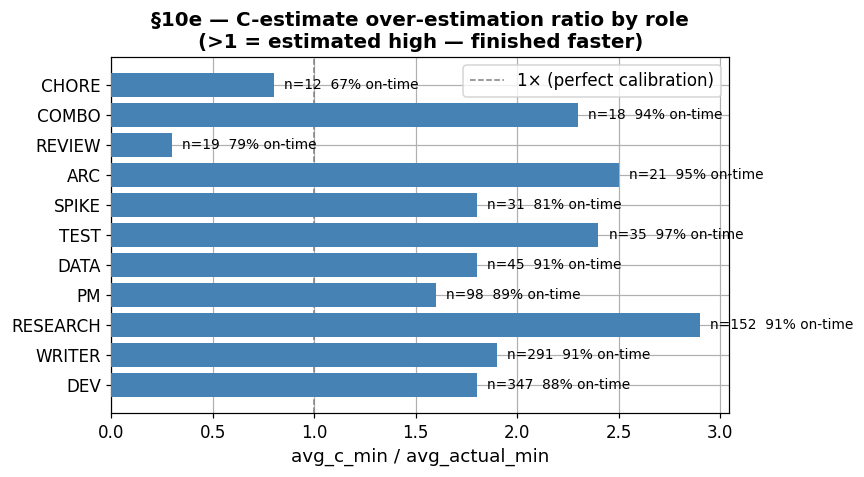

In [23]:
# §10e — C-estimate calibration by role (lccjs.db, same cal subset as §1–§6)
role_calib_rows = []
for r, g in cal.groupby("role"):
    cr = g["c_ratio"].values
    role_calib_rows.append({
        "role": r,
        "n": len(cr),
        "avg_actual_min": round(g["actual_min"].mean(), 1),
        "avg_c_min": round(g["c_min"].mean(), 1),
        "c_actual_ratio": round(g["c_min"].mean() / g["actual_min"].mean(), 1),
        "pct_on_time": round(100 * (cr >= 1.0).sum() / len(cr), 0),
    })
role_calib_df = (
    pd.DataFrame(role_calib_rows)
    .sort_values("n", ascending=False)
    .reset_index(drop=True)
)
display(role_calib_df.style
        .set_caption("§10e — C-estimate calibration by role  (cal subset from lccjs.db)")
        .hide(axis="index"))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(role_calib_df["role"], role_calib_df["c_actual_ratio"], color="steelblue", zorder=3)
for _, row in role_calib_df.iterrows():
    ax.text(row["c_actual_ratio"] + 0.05, row["role"],
            f'n={row["n"]}  {row["pct_on_time"]:.0f}% on-time', va="center", fontsize=9)
ax.axvline(1.0, color="grey", ls="--", lw=1, label="1× (perfect calibration)")
ax.set_xlabel("avg_c_min / avg_actual_min")
ax.set_title("§10e — C-estimate over-estimation ratio by role\n(>1 = estimated high — finished faster)")
ax.legend()
plt.tight_layout()
plt.show()